In [19]:
import functools as ft

import cloudpickle
import jax
import jax.numpy as jnp
import lz4.frame
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

To jest spakowana struktura, więc żeby ją wczytać:

In [20]:
with lz4.frame.open('history_5_5_42.pkl.lz4', 'rb') as f:
    carry, history = cloudpickle.load(f)

Dodatkowo tam jest zaaplikowany vmap, więc żeby dostać się do parametrów agenta "i" trzeba:

In [21]:
i = 2
t = 3

params_i = {'params': jax.tree.map(lambda x: x[i], carry.params)}
net_state_i = jax.tree.map(lambda x: x[i], carry.net_state)
variables_i = params_i | net_state_i

Natomiast obserwacja z kroku "t" dla agenta "i" to klasycznie:

In [22]:
env_state = history.observations[t][i]

A reszta wiadomo, prosty model flaxowy, który importujemy z:

In [23]:
from ltc.agents.svi import StochasticVariationalNetwork
from ltc.agents import QNetwork

qnetwork = StochasticVariationalNetwork(
            QNetwork(num_actions=3, num_layers=4, dim=64, num_heads=4))
qnetwork.apply(variables_i, env_state, rngs=jax.random.key(42), mutable=['loss'])[0]

Array([[1799.0997, 1799.3629, 1800.0206],
       [1799.6052, 1799.708 , 1800.3405],
       [1799.6053, 1799.7081, 1800.3406],
       [1799.6055, 1799.7081, 1800.3406],
       [1799.0995, 1799.3632, 1800.0204]], dtype=float32)

In [24]:
print("observations shape:", history.observations.shape)
print("params shapes:", jax.tree.map(lambda x: x.shape, carry.params))

observations shape: (50, 5000, 5, 1, 5)
params shapes: {'Dense_0/bias': {'log_scale': (5, 64)}, 'Dense_0/kernel': {'log_scale': (5, 5, 64)}, 'Dense_1/bias': {'log_scale': (5, 3)}, 'Dense_1/kernel': {'log_scale': (5, 64, 3)}, 'Transformer_0/LayerNorm_0/bias': {'log_scale': (5, 64)}, 'Transformer_0/LayerNorm_0/scale': {'log_scale': (5, 64)}, 'Transformer_0/TransformerBlock_0/FeedForwardBlock_0/Dense_0/bias': {'log_scale': (5, 256)}, 'Transformer_0/TransformerBlock_0/FeedForwardBlock_0/Dense_0/kernel': {'log_scale': (5, 64, 256)}, 'Transformer_0/TransformerBlock_0/FeedForwardBlock_0/Dense_1/bias': {'log_scale': (5, 64)}, 'Transformer_0/TransformerBlock_0/FeedForwardBlock_0/Dense_1/kernel': {'log_scale': (5, 256, 64)}, 'Transformer_0/TransformerBlock_0/LayerNorm_0/bias': {'log_scale': (5, 64)}, 'Transformer_0/TransformerBlock_0/LayerNorm_0/scale': {'log_scale': (5, 64)}, 'Transformer_0/TransformerBlock_0/LayerNorm_1/bias': {'log_scale': (5, 64)}, 'Transformer_0/TransformerBlock_0/LayerNorm

In [25]:
@jax.jit
@ft.partial(jax.vmap, in_axes=(None, 0))  # vmap po czasie (observations[t])
@ft.partial(jax.vmap, in_axes=(0, 0))      # vmap po agentach (params[i], observations[t][i])
def apply(params, state):
    return qnetwork.apply(params, state, rngs=jax.random.key(42), mutable=['loss'])[0]

variables = {'params': carry.params} | carry.net_state
q = apply(variables, history.observations)


ValueError: vmap got inconsistent sizes for array axes to be mapped:
  * most axes (181 of them) had size 5, e.g. axis 0 of argument params['loss']['Dense_0/kernel']['kl'] of type float32[5,64];
  * one axis had size 5000: axis 0 of argument state of type int32[5000,5,1,5]

In [7]:
q.shape

(10000, 10, 1, 2)

In [8]:
def plot_q(q):
    fig, axs = plt.subplots(nrows=q.shape[1], sharex=True, sharey=True, figsize=(4, 40))

    for i,ax in enumerate(axs):
        ax.scatter(q[:,i,0,0], q[:,i,0,1], alpha=0.1)
        ax.set_aspect('equal')
        ax.set_title(f'agent{i}')
        ax.set_xlim(-5, 0)
        ax.set_ylim(-5, 0)

    plt.savefig('plot_q.pdf')
    plt.show()

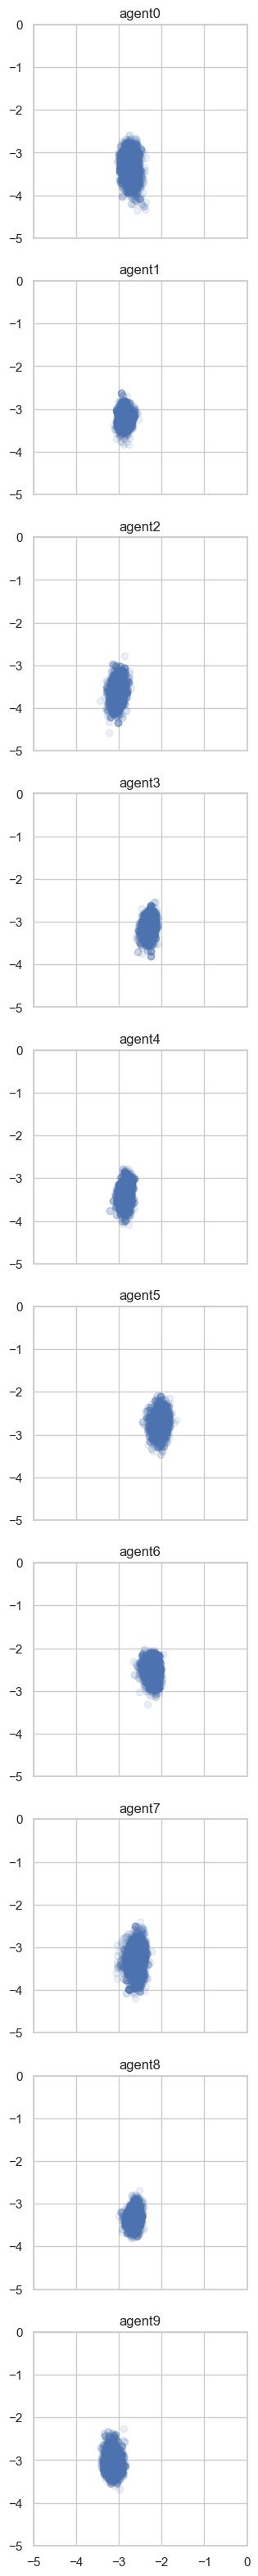

In [9]:
plot_q(q)

# Average

In [10]:
def average_params(x):
    a = jnp.mean(x, axis=0, keepdims=True)
    y = jnp.repeat(a, x.shape[0], axis=0)
    return y

aparams = jax.tree.map(average_params, variables)
aq = apply(aparams, history.observations)

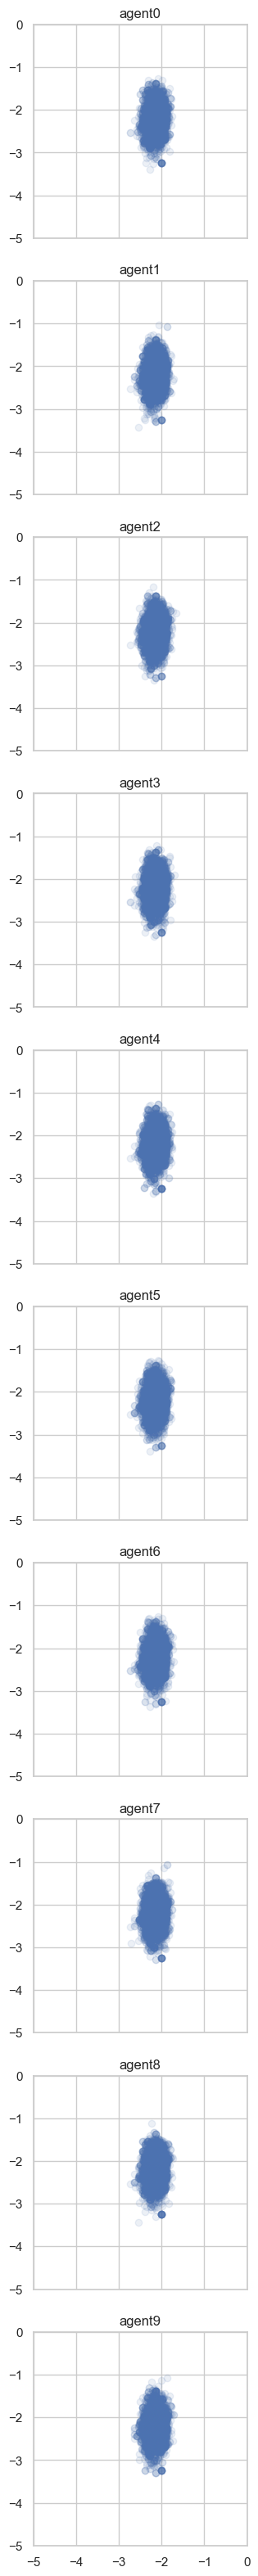

In [11]:
plot_q(aq)

In [12]:
def take_n(x, n):
    a = x[n]
    a = jnp.expand_dims(a, 0)
    y = jnp.repeat(a, x.shape[0], axis=0)
    return y

In [13]:
p0 = jax.tree.map(ft.partial(take_n, n=0), variables)
q0 = apply(p0, history.observations)

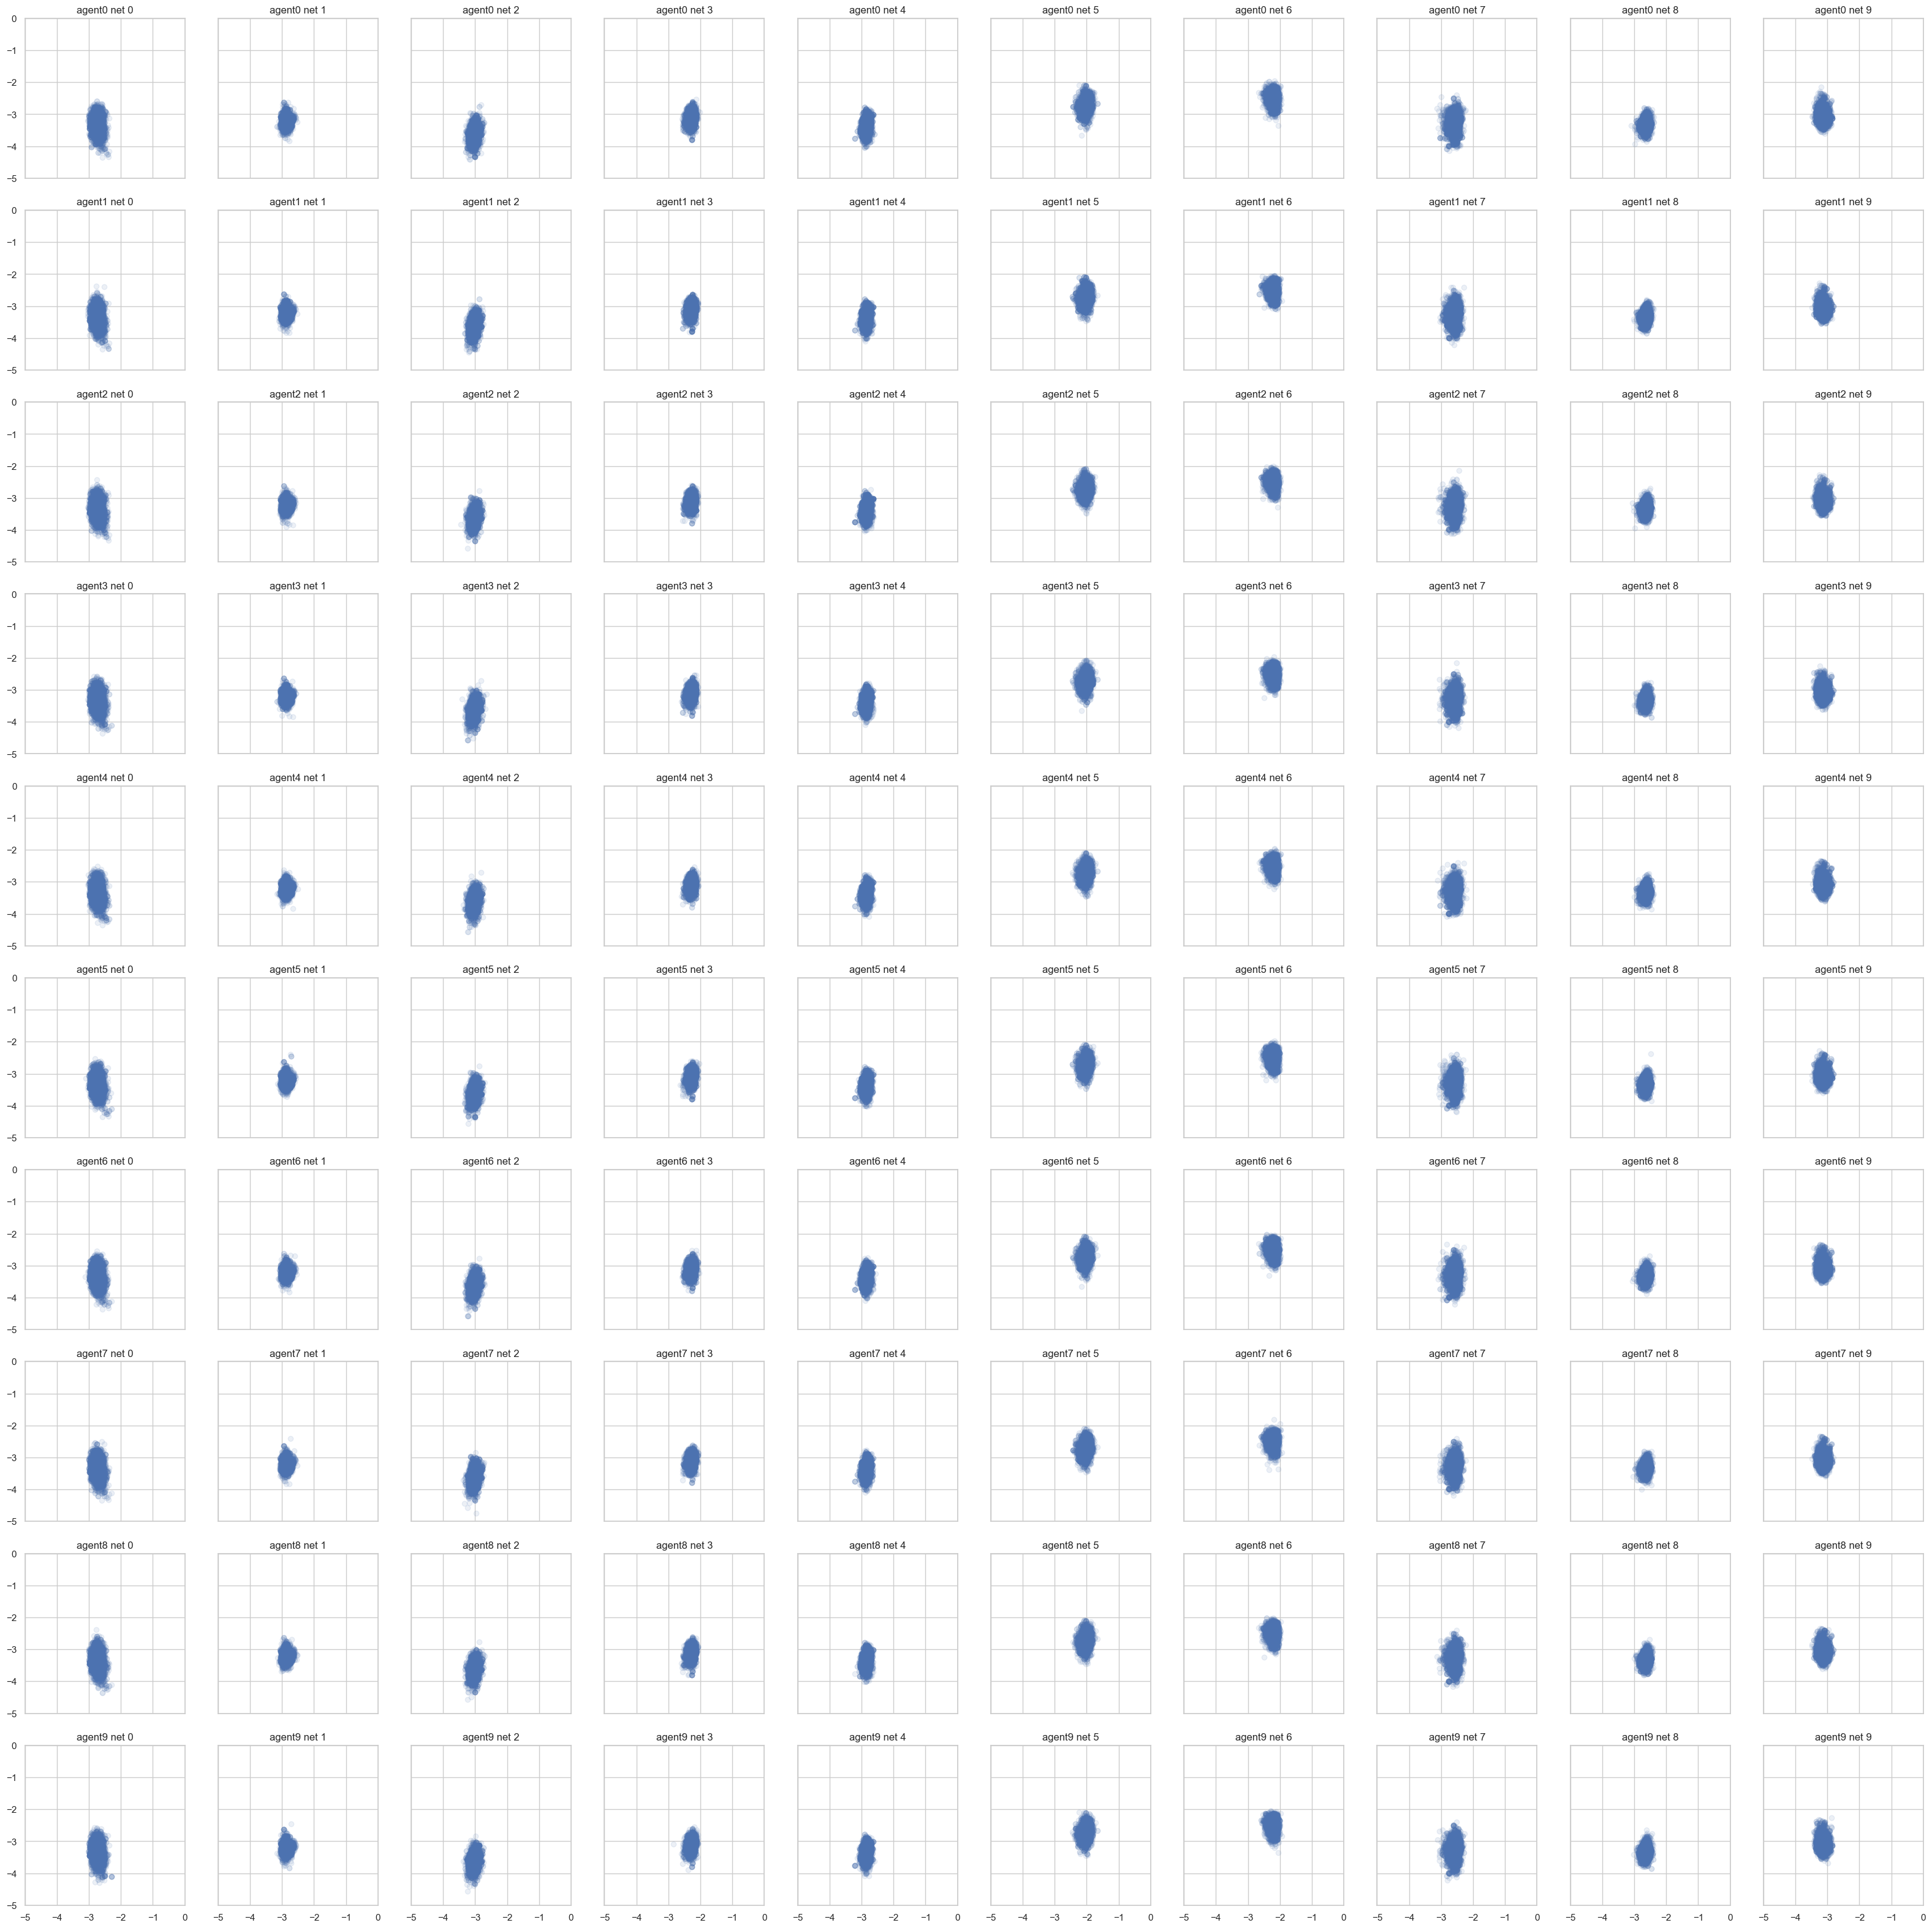

In [14]:
fig, axs = plt.subplots(nrows=q.shape[1], ncols=q.shape[1], sharex=True, sharey=True, figsize=(40, 40))

for i in range(q.shape[1]):
    for j in range(q.shape[1]):
        ax = axs[i, j]
        p_j = jax.tree.map(ft.partial(take_n, n=j), variables)
        q_j = apply(p_j, history.observations)
        ax.scatter(q_j[:,i,0,0], q_j[:,i,0,1], alpha=0.1)
        ax.set_aspect('equal')
        ax.set_title(f'agent{i} net {j}')
        ax.set_xlim(-5, 0)
        ax.set_ylim(-5, 0)

plt.savefig('all.pdf')
plt.show()